### Import libraries

In [13]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import math

In [14]:
printing = False
plotting = True

### Default functions

In [15]:

def inches(meters):
    return 1/0.0254 * meters

def meters(inches):
    return 0.0254 * inches

def weight(density, length, diameter, thickness):
    return 9.81 * density * length * np.pi * diameter * thickness

def buoyancy(density, length, diameter, thickness):
    return 9.81 * density *np.pi/4 * (diameter * thickness)**2 * length

def length(x1, x2, y1=0, y2=0, z1=0, z2=0):
    return np.sqrt((x1-x2)**2 + (y1-y2)**2 + (z1-z2)**2)

def norm_type(t: str) -> str:
    s = str(t).strip().upper()
    if s in ("LEG", "L"):
        return "Leg"
    if s == "H":
        return "H"
    if s == "K":
        return "K"
    return s

def parse_nodes_connected(value):
    if pd.isna(value):
        return None
    s = str(value).strip()
    m = re.fullmatch(r"\s*(\d+)\s*-\s*(\d+)\s*", s)
    if not m:
        return None
    return int(m.group(1)), int(m.group(2))

# Calculate the equivalant beam
def equivalent_beam_properties(h_i, I_top_i, I_bottom_i, M_legs_total, M_bracing_total, E):
    h_i = np.asarray(h_i, dtype=float)
    I_top_i = np.asarray(I_top_i, dtype=float)
    I_bottom_i = np.asarray(I_bottom_i, dtype=float)

    if not (len(h_i) == len(I_top_i) == len(I_bottom_i)):
        raise ValueError("h_i, I_top_i, I_bottom_i must have same length")
    if np.any(h_i <= 0):
        raise ValueError("All h_i must be > 0")

    I_mean_i = 0.5 * (I_top_i + I_bottom_i)
    M_total = M_legs_total + M_bracing_total
    L_total = np.sum(h_i)
    m_eq = M_total / L_total # kg/m, uniform over full height
    m_i = np.full_like(h_i, m_eq) # same m per unit length in every bay
    EI_eq = E * (np.sum(I_mean_i * h_i) / L_total) # height-weighted average EI

    return m_i, I_mean_i, m_eq, EI_eq

# Function for the first natural frequency, based on the memo
def first_frequency_cantilever(EI, m, L, Mtop):
    f1 = (1.0 / (2.0 * np.pi)) * np.sqrt((3.04 * EI) / (((0.227 * m * L) + Mtop) * (L ** 3)))
    return f1


def section_inertia_from_leg_layout(z_level, nodes_3d, leg_node_ids, A_leg_m2):
    # Nodes at this elevation
    pts = [(nodes_3d[n][0], nodes_3d[n][1]) for n in leg_node_ids if np.isclose(nodes_3d[n][2], z_level)]
    if len(pts) < 3:
        raise ValueError(f"Not enough leg nodes at z={z_level} to build section inertia")

    x = np.array([p[0] for p in pts], dtype=float)
    y = np.array([p[1] for p in pts], dtype=float)
    x_c, y_c = np.mean(x), np.mean(y)

    # Using cross-section areas and steiner
    I_x = np.sum(A_leg_m2 * (y - y_c) ** 2)
    I_y = np.sum(A_leg_m2 * (x - x_c) ** 2)
    return 0.5 * (I_x + I_y)

def welding_angle(node1, node2, node3, node4):
    x1, y1, z1 = node1
    x2, y2, z2 = node2
    x3, y3, z3 = node3
    x4, y4, z4 = node4

    u = (x2-x1, y2-y1, z2-z1)
    v= (x4-x3, y4-y3, z4-z3)

    dot = u[0]*v[0] + u[1]*v[1] + u[2]*v[2]
    magu = length(x1, x2, y1, y2, z1, z2)
    magv = length(x3, x4, y3, y4, z3, z4)

    cos_theta = dot /(magu * magv)

    angle = np.acos(cos_theta)

    return angle


### Setup of the geometry

In [16]:

file_path = "Data.xlsx"
geom_df = pd.read_excel(file_path, sheet_name="Geometry")
conn_df = pd.read_excel(file_path, sheet_name="Members")


# Read 3D nodes
node_df = geom_df[
    geom_df["Nodes"].notna() &
    geom_df["X"].notna() &
    geom_df["Y"].notna() &
    geom_df["Z"].notna()
].copy()

nodes_3d = {
    int(row["Nodes"]): (float(row["X"]), float(row["Y"]), float(row["Z"]))
    for _, row in node_df.iterrows()
}


# Read members
elem_df = conn_df[conn_df["Members"].notna()].copy()
elements = []

for _, row in elem_df.iterrows():
    elem_id = int(row["Members"])
    elem_type = str(row["Element type"]).strip()      
    parsed = parse_nodes_connected(row["Connectivity"])  

    if parsed is None:
        continue

    n1, n2 = parsed
    if n1 not in nodes_3d or n2 not in nodes_3d:
        continue

    x1, y1, z1 = nodes_3d[n1]
    x2, y2, z2 = nodes_3d[n2]

    seg_len = round(float(length(x1, x2, y1, y2, z1, z2)), 3)
    elements.append({
        "id": elem_id,
        "type": elem_type,
        "nodes": (n1, n2),
        "length": seg_len,
        "length_eff": seg_len,
        "leg_id": None,
    })


leg_indices = [i for i, e in enumerate(elements) if norm_type(e["type"]) == "Leg"]

if len(leg_indices) % 5 != 0:
    raise ValueError(f"Leg segment count must be multiple of 5, found {len(leg_indices)}")

for g in range(0, len(leg_indices), 5):
    idx_group = leg_indices[g:g+5]

    first_elem = elements[idx_group[0]]
    last_elem = elements[idx_group[-1]]

    n_start = first_elem["nodes"][0]
    n_end = last_elem["nodes"][1]

    x1, y1, z1 = nodes_3d[n_start]
    x2, y2, z2 = nodes_3d[n_end]
    full_leg_length = round(float(length(x1, x2, y1, y2, z1, z2)), 3)

    for i in idx_group:
        elements[i]["length_eff"] = full_leg_length   # full length for sizing only
        elements[i]["leg_id"] = g // 5 + 1            # 1-indexed leg number (1–4)
        # elements[i]["length"] stays as the actual segment length


#### Welding angles

### Design of structure with answer to Weights and first frequency

In [17]:

df = pd.DataFrame(elements).rename(columns={
    "id": "Number",
    "type": "Element type",
    "length": "L_m",
    "length_eff": "L_eff_m",
})

df["read_order"] = np.arange(len(df))

# Normalize element types
df["Element type"] = (
    df["Element type"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({"H": "H", "K": "K", "LEG": "Leg", "L": "Leg"})
)

# Numeric safety
df["Number"]  = pd.to_numeric(df["Number"],  errors="coerce")
df["L_m"]     = pd.to_numeric(df["L_m"],     errors="coerce")
df["L_eff_m"] = pd.to_numeric(df["L_eff_m"], errors="coerce")

gamma_s = 7850.0  # kg/m^3
x = {"H": 0.023, "K": 0.029}   # Leg diameter is derived separately
d_over_t = {"H": 40.0, "K": 40.0, "Leg": 60.0}
E      = 210e9    # Pa
rho_sw = 1025.0   # seawater density [kg/m³]
z_MSL  = 52.0     # mean sea level elevation [m]

# Top structure inputs
M_top = 2072*1000   # [kg] — mass of deck + topsides
h_hub = 150.0       # [m]  — hub height above jacket top

# Diameter sizing
df["D_m"] = df["L_eff_m"] * df["Element type"].map(x)
df["D(inches)"] = inches(df["D_m"].fillna(0))
df["Chosen diameter (inches)"] = np.ceil(df["D(inches)"] / 2) * 2   # round up to nearest even inch

# Legs: max H/K chosen diameter
max_hk_diam = df.loc[df["Element type"].isin(["H", "K"]), "Chosen diameter (inches)"].max()
df.loc[df["Element type"].eq("Leg"), "Chosen diameter (inches)"] = max_hk_diam + 8 # Diameter of the leg by hand


# Thickness sizing
df["D_over_t"] = df["Element type"].map(d_over_t)
hk_last4_idx = (
    df.loc[df["Element type"].isin(["H", "K"])]
      .sort_values("read_order")
      .tail(4)
      .index
)
df.loc[hk_last4_idx, "D_over_t"] = 25.0

df["Thickness(inches)"] = df["Chosen diameter (inches)"] / df["D_over_t"]
df["Chosen thickness (inches)"] = np.ceil(df["Thickness(inches)"] / 0.125) * 0.125
df.loc[df["Element type"].eq("Leg"), "Chosen thickness (inches)"] += 0.125 # Thickness of the leg by hand

# Section properties
D = df["Chosen diameter (inches)"]
t = df["Chosen thickness (inches)"]
df["Cross section area (inch2)"] = math.pi * D * t
df["Inertia (inch4)"] = (math.pi / 8.0) * (D ** 3) * t
A_m2 = meters(meters(df["Cross section area (inch2)"]))
df["Mass (t)"]    = (A_m2 * df["L_m"] * gamma_s) / 1000.0
df["Weight (kN)"] = df["Mass (t)"] * 9.81

# Buoyancy
# Submerged length fraction for each element
def _sub_frac(nodes_pair):
    z1 = nodes_3d[nodes_pair[0]][2]
    z2 = nodes_3d[nodes_pair[1]][2]
    za, zb = min(z1, z2), max(z1, z2)
    if zb <= z_MSL: return 1.0
    if za >= z_MSL: return 0.0
    return (z_MSL - za) / (zb - za)

df["L_sub_m"] = df["L_m"] * df["nodes"].apply(_sub_frac)

D_m_b = D * 0.0254   # outer diameter [m]
t_m_b = t * 0.0254   # wall thickness [m]
is_leg = df["Element type"].eq("Leg")

# H/K (watertight): buoyancy = ρ_sw·g·(π/4·D²)·L_sub
df["Buoyancy (kN)"] = (rho_sw * 9.81 * (math.pi / 4) * D_m_b**2 * df["L_sub_m"]) / 1000.0
df.loc[is_leg, "Buoyancy (kN)"] = (
    rho_sw * 9.81 * math.pi * D_m_b[is_leg] * t_m_b[is_leg] * df.loc[is_leg, "L_sub_m"]
) / 1000.0

df["Subm. weight (kN)"] = df["Weight (kN)"] - df["Buoyancy (kN)"]


# Output table
out = df.sort_values("Number").reset_index(drop=True)

if printing:
    _cols_first = ["Number", "Element type", "L_eff_m",
                   "Chosen diameter (inches)", "Chosen thickness (inches)",
                   "Cross section area (inch2)", "Inertia (inch4)"]
    _cols_sum   = ["L_m", "Mass (t)", "Weight (kN)", "Buoyancy (kN)", "Subm. weight (kN)"]
    _leg_agg = (
        out[out["Element type"] == "Leg"]
        .groupby("leg_id", sort=True)
        .agg(**{c: (c, "first") for c in _cols_first},
             **{c: (c, "sum")   for c in _cols_sum})
        .reset_index(drop=True)
    )
    _nonleg = out[out["Element type"] != "Leg"]
    _display = (
        pd.concat([_leg_agg, _nonleg], ignore_index=True)
        .sort_values("Number")
        .reset_index(drop=True)
    )
    print(_display[[
        "Number", "Element type", "L_m", "L_eff_m",
        "Chosen diameter (inches)", "Chosen thickness (inches)",
        "Cross section area (inch2)", "Mass (t)", "Inertia (inch4)",
        "Weight (kN)", "Buoyancy (kN)", "Subm. weight (kN)"
    ]].round(3))

# ── Mass/buoyancy totals ───────────────────────────────────────────────────────
M_legs_total    = out.loc[out["Element type"].eq("Leg"),           "Mass (t)"].sum() * 1000.0
M_bracing_total = out.loc[out["Element type"].isin(["H", "K"]),   "Mass (t)"].sum() * 1000.0
B_total         = out["Buoyancy (kN)"].sum()
W_dry_total     = out["Weight (kN)"].sum()
W_sub_total     = out["Subm. weight (kN)"].sum()

print(f"\nMass & buoyancy summary (z_MSL = {z_MSL} m):")
print(f"  Total dry weight   = {W_dry_total:>10,.1f} kN  ({W_dry_total/9.81:,.1f} t)")
print(f"  Total buoyancy     = {B_total:>10,.1f} kN")
print(f"  Total subm. weight = {W_sub_total:>10,.1f} kN  ({W_sub_total/9.81:,.1f} t)")

# ── Equivalent beam & natural frequency ───────────────────────────────────────
A_leg_m2 = out.loc[out["Element type"].eq("Leg"), "Cross section area (inch2)"].mean() * 0.00064516

leg_elems    = [e for e in elements if norm_type(e["type"]) == "Leg"]
leg_node_ids = sorted(set([n for e in leg_elems for n in e["nodes"]]))
z_levels     = sorted(set([nodes_3d[n][2] for n in leg_node_ids]))
if len(z_levels) < 2:
    raise ValueError("Need at least two leg elevation levels")

h_i        = np.diff(z_levels)
n_segments = len(h_i)
n_bays     = n_segments - 2

def segment_label(j, n_segments):
    if j == 0:              return "Stub(bot)"
    if j == n_segments - 1: return "Stub(top)"
    return f"Bay {j}"

I_levels   = np.array(
    [section_inertia_from_leg_layout(z, nodes_3d, leg_node_ids, A_leg_m2) for z in z_levels],
    dtype=float)
I_bottom_i = I_levels[:-1]
I_top_i    = I_levels[1:]

m_i, I_mean_i, m_eq, EI_eq = equivalent_beam_properties(
    h_i, I_top_i, I_bottom_i, M_legs_total, M_bracing_total, E)
L_jacket = np.sum(h_i)
L_total  = L_jacket + h_hub
f1       = first_frequency_cantilever(EI_eq, m_eq, L_total, M_top)

print(f"\nStructure: {n_bays} structural bays + 2 stubs  |  L_jacket = {L_jacket:.2f} m  |  L_total = {L_total:.2f} m  |  M_top = {M_top/1e3:,.0f} t")
print(f"{'Segment':<12}  {'z_bot[m]':>9}  {'z_top[m]':>9}  {'h_i[m]':>7}  {'I_mean[m4]':>13}  {'EI_i[N·m2]':>14}  {'m_i[kg/m]':>11}")
for j in range(n_segments):
    lbl = segment_label(j, n_segments)
    print(f"{lbl:<12}  {z_levels[j]:>9.2f}  {z_levels[j+1]:>9.2f}  {h_i[j]:>7.3f}  {I_mean_i[j]:>13.4e}  {E*I_mean_i[j]:>14.4e}  {m_i[j]:>11.2f}")

print("\nEquivalent beam results:")
print(f"  M_legs_total [kg]    = {M_legs_total:,.2f}")
print(f"  M_bracing_total [kg] = {M_bracing_total:,.2f}")
print(f"  M_jacket [kg]        = {M_legs_total + M_bracing_total:,.2f}")
print(f"  M_top [kg]           = {M_top:,.2f}")
print(f"  m_eq [kg/m]          = {m_eq:,.3f}")
print(f"  EI_eq [N·m^2]        = {EI_eq:,.3e}")
print(f"  L_total [m]          = {L_total:.2f}")
print(f"  f1 [Hz]              = {f1:,.4f}")



Mass & buoyancy summary (z_MSL = 52.0 m):
  Total dry weight   =    4,021.2 kN  (409.9 t)
  Total buoyancy     =    2,545.2 kN
  Total subm. weight =    1,476.1 kN  (150.5 t)

Structure: 3 structural bays + 2 stubs  |  L_jacket = 63.67 m  |  L_total = 213.67 m  |  M_top = 2,072 t
Segment        z_bot[m]   z_top[m]   h_i[m]     I_mean[m4]      EI_i[N·m2]    m_i[kg/m]
Stub(bot)          0.00       1.00    1.000     6.3659e+01      1.3368e+13      6438.35
Bay 1              1.00      26.31   25.314     5.1922e+01      1.0904e+13      6438.35
Bay 2             26.31      46.53   20.213     3.2890e+01      6.9068e+12      6438.35
Bay 3             46.53      62.67   16.140     2.0753e+01      4.3581e+12      6438.35
Stub(top)         62.67      63.67    1.000     1.6060e+01      3.3727e+12      6438.35

Equivalent beam results:
  M_legs_total [kg]    = 196,474.96
  M_bracing_total [kg] = 213,435.33
  M_jacket [kg]        = 409,910.29
  M_top [kg]           = 2,072,000.00
  m_eq [kg/m]     

In [18]:
# ── Export geometry + designed diameters to the hydrodynamic loads notebook ──
# Build a members list with the actual designed outer diameters (in metres)
_id_to_D_m = dict(zip(df["Number"], df["Chosen diameter (inches)"] * 0.0254))

members_hydro = [
    {
        'start': elem['nodes'][0],
        'end':   elem['nodes'][1],
        'D':     _id_to_D_m[elem['id']],
    }
    for elem in elements
    if elem['id'] in _id_to_D_m
]

%store nodes_3d
%store members_hydro
print(f"Stored {len(nodes_3d)} nodes and {len(members_hydro)} members for hydro notebook.")


Stored 'nodes_3d' (dict)
Stored 'members_hydro' (list)
Stored 24 nodes and 48 members for hydro notebook.


In [19]:
len(nodes_3d.items())

24

### Plot of the structure

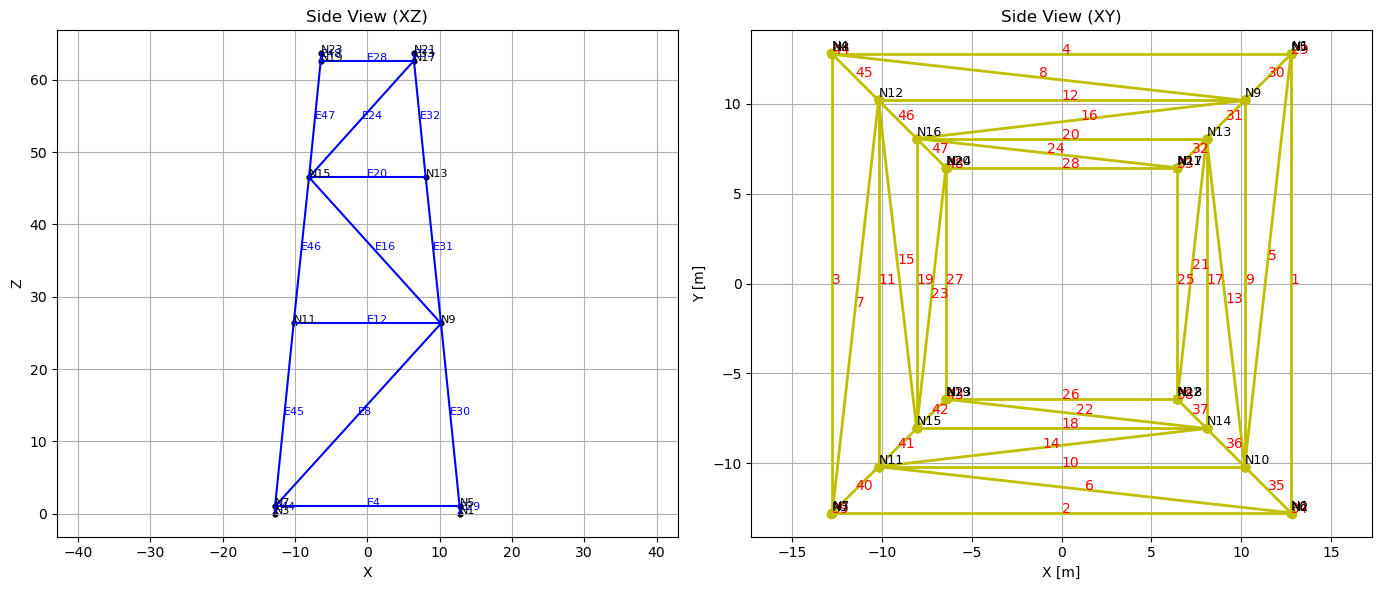

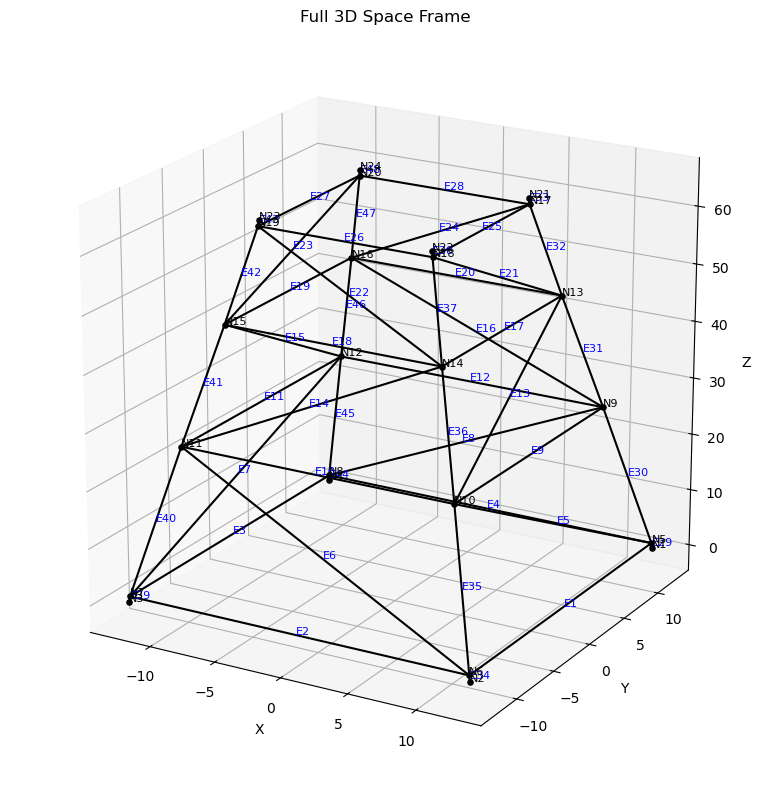

In [20]:

# Side views (XZ and XY) side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Side view (XZ)
ax1.set_title("Side View (XZ)")
ax1.set_xlabel("X")
ax1.set_ylabel("Z")
ax1.axis("equal")
ax1.grid(True)

for elem in elements:
    if nodes_3d[elem["nodes"][0]][1] > 0 and nodes_3d[elem["nodes"][1]][1] > 0:
        n1, n2 = elem["nodes"]
        x1, y1, z1 = nodes_3d[n1]
        x2, y2, z2 = nodes_3d[n2]
        ax1.plot([x1, x2], [z1, z2], "b")
        xm, zm = (x1 + x2) / 2.0, (z1 + z2) / 2.0
        ax1.text(xm, zm, f"E{elem['id']}", color="blue", fontsize=8)

for nid, (x, y, z) in nodes_3d.items():
    if nid%2 == 1:
        ax1.scatter(x, z, c="black", s=12)
        ax1.text(x, z, f"N{nid}", color="black", fontsize=8)

# Side view (XY)
ax2.set_title("Side View (XY)")
ax2.set_xlabel("X [m]")
ax2.set_ylabel("Y [m]")
ax2.axis("equal")
ax2.grid(True)

for elem in elements:
    n1, n2 = elem["nodes"]
    x1, y1, z1 = nodes_3d[n1]
    x2, y2, z2 = nodes_3d[n2]
    ax2.plot([x1, x2], [y1, y2], "y-o", linewidth=2)
    xm, ym = (x1 + x2) / 2, (y1 + y2) / 2
    ax2.text(xm, ym, str(elem["id"]), color="red", fontsize=10)

for nid, (x, y, z) in nodes_3d.items():
    ax2.text(x, y, f"N{nid}", color="black", fontsize=9, verticalalignment="bottom")

plt.tight_layout()
plt.show()

# 3D view
fig3d = plt.figure(figsize=(10, 8))
ax3d = fig3d.add_subplot(111, projection="3d")

ax3d.set_title("Full 3D Space Frame")
ax3d.set_xlabel("X")
ax3d.set_ylabel("Y")
ax3d.set_zlabel("Z")

for elem in elements:
    n1, n2 = elem["nodes"]
    x1, y1, z1 = nodes_3d[n1]
    x2, y2, z2 = nodes_3d[n2]
    ax3d.plot([x1, x2], [y1, y2], [z1, z2], "k")
    xm, ym, zm = (x1 + x2) / 2.0, (y1 + y2) / 2.0, (z1 + z2) / 2.0
    ax3d.text(xm, ym, zm, f"E{elem['id']}", color="blue", fontsize=8)

for nid, (x, y, z) in nodes_3d.items():
    ax3d.scatter(x, y, z, c="black", s=14)
    ax3d.text(x, y, z, f"N{nid}", color="black", fontsize=8)

ax3d.set_box_aspect([1, 1, 1])
ax3d.view_init(elev=20, azim=-60)   # oblique view
plt.tight_layout()
plt.show()


### ELement overview

In [21]:

# Print element dimensions using values already computed above (no recalculation)
# Consolidate leg segments into one row per leg for display
_cols_first = ["Number", "Element type", "L_eff_m",
               "Chosen diameter (inches)", "Chosen thickness (inches)", "Inertia (inch4)"]
_cols_sum   = ["L_m", "Mass (t)", "Weight (kN)", "Buoyancy (kN)", "Subm. weight (kN)"]
_leg_agg = (
    out[out["Element type"] == "Leg"]
    .groupby("leg_id", sort=True)
    .agg(**{c: (c, "first") for c in _cols_first},
         **{c: (c, "sum")   for c in _cols_sum})
    .reset_index(drop=True)
)
_display = (
    pd.concat([_leg_agg, out[out["Element type"] != "Leg"]], ignore_index=True)
    .sort_values("Number")
    .reset_index(drop=True)
)

print("\nElement dimensions, thicknesses, weight and buoyancy:")
for _, row in _display.iterrows():
    print(
        f"Element {int(row['Number'])}: "
        f"Length: {row['L_m']:.3f} m, "
        f"Weight = {row['Weight (kN)']:.2f} kN, "
        f"Buoyancy = {row['Buoyancy (kN)']:.2f} kN, "
        f"Subm. weight = {row['Subm. weight (kN)']:.2f} kN"
    )



Element dimensions, thicknesses, weight and buoyancy:
Element 1: Length: 25.530 m, Weight = 59.77 kN, Buoyancy = 74.92 kN, Subm. weight = -15.15 kN
Element 2: Length: 25.530 m, Weight = 59.77 kN, Buoyancy = 74.92 kN, Subm. weight = -15.15 kN
Element 3: Length: 25.530 m, Weight = 59.77 kN, Buoyancy = 74.92 kN, Subm. weight = -15.15 kN
Element 4: Length: 25.530 m, Weight = 59.77 kN, Buoyancy = 74.92 kN, Subm. weight = -15.15 kN
Element 5: Length: 34.271 m, Weight = 213.97 kN, Buoyancy = 279.38 kN, Subm. weight = -65.42 kN
Element 6: Length: 34.271 m, Weight = 213.97 kN, Buoyancy = 279.38 kN, Subm. weight = -65.42 kN
Element 7: Length: 34.271 m, Weight = 213.97 kN, Buoyancy = 279.38 kN, Subm. weight = -65.42 kN
Element 8: Length: 34.271 m, Weight = 213.97 kN, Buoyancy = 279.38 kN, Subm. weight = -65.42 kN
Element 9: Length: 20.386 m, Weight = 31.82 kN, Buoyancy = 41.55 kN, Subm. weight = -9.73 kN
Element 10: Length: 20.386 m, Weight = 31.82 kN, Buoyancy = 41.55 kN, Subm. weight = -9.73 k

### Hydrodynamic loads and Stick model

#### General hydro part

In [22]:

# Hydrodynamic loads using Morrison's equation

H = 13.6        # wave height [m]
T = 15.0        # wave period [s]
z_MSL_abs = 52.0   # mean sea level absolute elevation [m above seabed]
phase = np.pi/4

rho = 1025
CD  = 1.0
CM  = 2.0

# ── Marine growth ─────────────────────────────────────────────────────────────
t_mg     = 0.050   # marine growth thickness [m]
z_mg_bot = 2.0     # lower absolute elevation for marine growth [m above seabed]
z_mg_top = 40.0    # upper absolute elevation for marine growth [m above seabed]

# ── Debug / verbose flag ───────────────────────────────────────────────────────
verbose = True     # True → print step-by-step diagnostics

def hydro_diameter(D_struct, z_abs):
    """Structural diameter + marine growth if z_abs is within [z_mg_bot, z_mg_top]."""
    return D_struct + 2 * t_mg if z_mg_bot <= z_abs <= z_mg_top else D_struct

# Build members list from designed diameters
_id_to_D_m = dict(zip(df["Number"], df["Chosen diameter (inches)"] * 0.0254))
members_hydro = [
    {'start': e['nodes'][0], 'end': e['nodes'][1], 'D': _id_to_D_m[e['id']]}
    for e in elements if e['id'] in _id_to_D_m
]
nodes   = nodes_3d
members = members_hydro

z_levels_all = sorted({round(v[2], 3) for v in nodes.values()})

g = 9.81

def wave_number(T, h):
    omega = 2*np.pi/T
    k = omega**2/g
    for _ in range(100):
        f   = g*k*np.tanh(k*h) - omega**2
        df_ = g*np.tanh(k*h) + g*k*h*(1/np.cosh(k*h))**2
        k  -= f/df_
    return k

def airy_kinematics(z, H, T, h, phase):
    omega = 2*np.pi/T
    k = wave_number(T, h)
    a = H/2
    u   = a*omega    * np.cosh(k*(z+h))/np.sinh(k*h) * np.cos(phase)
    a_x = a*omega**2 * np.cosh(k*(z+h))/np.sinh(k*h) * np.sin(phase)
    return u, a_x

def wheeler_z(z, zeta, h):
    return ((z+h)/(h+zeta))*h - h


# ──────────────────────────────────────────────────────────────────────────────
# STICK MODEL
#
# Equivalent diameters for panel [zL, zU] (relative to SWL), height E0:
#
#   Drag (Morison cross-flow):  normal velocity = u * p_yz/L
#     where p_yz = sqrt(dy²+dz²)  (member projection perpendicular to wave X)
#   Per-panel contribution of member clipped to panel (height dz_in):
#     D_de += D * p_yz² * dz_in / (L * |dz_m| * E0)
#     D_ie² += D² * p_yz * dz_in / (|dz_m| * E0)
#
#   Horizontal members (|dz_m|≈0) are computed as concentrated forces at z_h.
# ──────────────────────────────────────────────────────────────────────────────



#### Stick model

In [23]:
def stick_model(h, ranges, verbose=False):
    zeta  = H/2 * np.cos(phase)
    k     = wave_number(T, h)
    omega = 2*np.pi/T

    if verbose:
        print(f"\n{'═'*80}")
        print(f"  STICK MODEL  |  h = {h:.2f} m  |  ζ_crest = {zeta:.4f} m (rel. SWL)")
        print(f"  k = {k:.6f} rad/m   ω = {omega:.4f} rad/s")
        print(f"  Marine growth: z_abs ∈ [{z_mg_bot:.1f}, {z_mg_top:.1f}] m   t_mg = {t_mg*1e3:.0f} mm")
        print(f"{'═'*80}")

    results = []

    for zL, zU in ranges:
        E0 = abs(zU - zL)
        Dde_sq_sum = 0.0   # accumulates D_de contributions
        Die_sq_sum = 0.0   # accumulates D_ie² contributions
        F_conc     = 0.0   # concentrated force from horizontal members
        M_conc     = 0.0   # moment contribution from concentrated forces

        if verbose:
            print(f"\n  ┌─ Panel  z_rel ∈ [{zL:.3f}, {zU:.3f}] m"
                  f"   (z_abs ∈ [{zL+h:.2f}, {zU+h:.2f}] m)   E0 = {E0:.3f} m")
            print(f"  │  {'#':>3}  {'nodes':>9}  {'z_lo_abs':>9}  {'z_hi_abs':>9}  "
                  f"{'dz_in':>7}  {'D_str':>7}  {'mg?':>4}  {'D_hyd':>7}  "
                  f"{'p_yz':>7}  {'L':>7}  {'ΔDde':>10}  {'ΔDie²':>10}")

        for idx, m in enumerate(members):
            xi, yi, zi_raw = nodes[m['start']]
            xj, yj, zj_raw = nodes[m['end']]
            zi = zi_raw - h     # relative to SWL
            zj = zj_raw - h

            z_lo_mbr = min(zi, zj)
            z_hi_mbr = max(zi, zj)

            # ── filter: must intersect this panel AND be below wave crest ──
            if z_lo_mbr > zeta:              continue   # entirely above crest
            if z_hi_mbr < zL - 1e-9:        continue   # entirely below panel
            if z_lo_mbr > zU + 1e-9:        continue   # entirely above panel

            dx   = xj - xi
            dy   = yj - yi
            dz_m = zj - zi
            L    = np.sqrt(dx**2 + dy**2 + dz_m**2)
            if L == 0:
                continue

            z_mid_abs = (zi_raw + zj_raw) / 2.0
            D_struct  = m['D']
            D         = hydro_diameter(D_struct, z_mid_abs)
            mg_flag   = D > D_struct

            if abs(dz_m) < 1e-6:
                # ── horizontal member: concentrated force at its elevation ──
                z_h = zi           # relative to SWL
                if zL - 1e-9 <= z_h <= zU + 1e-9:
                    p_h  = np.sqrt(dx**2 + dy**2)   # plan-view length (= L for horizontal)
                    if z_h > zeta:
                        pass                         # above crest
                    else:
                        z_s_h    = wheeler_z(z_h, zeta, h)
                        u_h, a_h = airy_kinematics(z_s_h, H, T, h, phase)
                        fh = (0.5*rho*CD*D*p_h*u_h*abs(u_h)
                              + rho*CM*(np.pi/4)*D**2*p_h*a_h)
                        F_conc += fh
                        M_conc += fh * z_h
                        if verbose:
                            print(f"  │  {idx:>3}  {str(m['start'])+'-'+str(m['end']):>9}  "
                                  f"{zi_raw:>9.3f}  {zj_raw:>9.3f}  "
                                  f"{'HORIZ':>7}  {D_struct:>7.4f}  "
                                  f"{'YES' if mg_flag else 'no':>4}  {D:>7.4f}  "
                                  f"p_h={p_h:.3f}  F_h={fh:.2f} N  (concentrated)")
            else:
                # ── inclined / vertical member: clip to panel ──
                z_lo_clip = max(zL, z_lo_mbr)
                z_hi_clip = min(zU, z_hi_mbr)
                dz_in = z_hi_clip - z_lo_clip
                if dz_in <= 0:
                    continue

                p_yz = np.sqrt(dy**2 + dz_m**2)   # projection ⊥ wave direction

                # Correct panel-clipped equivalent diameter formulas:
                #   D_de = (1/E0) * Σ  D * p_yz² * dz_in / (L * |dz_m|)
                #   D_ie²= (1/E0) * Σ  D² * p_yz * dz_in / |dz_m|
                dDde   = D * p_yz**2 * dz_in / (L * abs(dz_m) * E0)
                dDie_sq= D**2 * p_yz * dz_in / (abs(dz_m) * E0)

                Dde_sq_sum += dDde
                Die_sq_sum += dDie_sq

                if verbose:
                    print(f"  │  {idx:>3}  {str(m['start'])+'-'+str(m['end']):>9}  "
                          f"{min(zi_raw,zj_raw):>9.3f}  {max(zi_raw,zj_raw):>9.3f}  "
                          f"{dz_in:>7.3f}  {D_struct:>7.4f}  "
                          f"{'YES' if mg_flag else 'no':>4}  {D:>7.4f}  "
                          f"{p_yz:>7.3f}  {L:>7.3f}  {dDde:>10.6f}  {dDie_sq:>10.6f}")

        Dde_sum = Dde_sq_sum          # already the summed D_de (linear, not squared)
        Die_sum = np.sqrt(Die_sq_sum)

        if verbose:
            print(f"  │  {'─'*78}")
            print(f"  │  Dde_sum = {Dde_sum:.6f} m    Die_sum = {Die_sum:.6f} m")
            print(f"  │  F_conc  = {F_conc:.2f} N  (horizontal members)")
            print(f"  │")
            print(f"  │  {'z_rel':>8}  {'z_abs':>8}  {'z_whl':>8}  {'u [m/s]':>9}  "
                  f"{'a [m/s²]':>9}  {'f_dist [N/m]':>14}  {'f_panel [N]':>13}")

        # ── Simpson 3-point integration over the panel ─────────────────────────
        z_pts  = [zU, (zU+zL)/2, zL]
        f_vals = []
        for z in z_pts:
            if z > zeta:
                f_vals.append(0.0)
                if verbose:
                    print(f"  │  {z:>8.4f}  {'above crest → 0':>50}")
                continue
            z_s    = wheeler_z(z, zeta, h)
            u, a_x = airy_kinematics(z_s, H, T, h, phase)
            f = 0.5*rho*CD*Dde_sum*u*abs(u) + rho*CM*(np.pi/4)*Die_sum**2*a_x
            f_vals.append(f)
            if verbose:
                print(f"  │  {z:>8.4f}  {z+h:>8.4f}  {z_s:>8.4f}  "
                      f"{u:>9.4f}  {a_x:>9.4f}  {f:>14.2f}  "
                      f"{E0/6*(f_vals[0] if len(f_vals)==1 else 0):>13.2f}")

        FR = E0/6*(f_vals[0] + 4*f_vals[1] + f_vals[2]) + F_conc
        MR = E0/6*(f_vals[0]*zU + 4*f_vals[1]*((zU+zL)/2) + f_vals[2]*zL) + M_conc

        if verbose:
            print(f"  └─ Panel Force = {FR:.2f} N    Panel Moment = {MR:.2f} N·m")

        results.append({'zU': zU, 'zL': zL, 'Force': FR, 'Moment_SWL': MR,
                        'Dde': Dde_sum, 'Die': Die_sum})

    F_total = sum(r['Force']      for r in results)
    M_total = sum(r['Moment_SWL'] for r in results)

    if verbose:
        print(f"\n  ► Total Base Shear  = {F_total:,.2f} N")
        print(f"  ► Total Base Moment = {M_total:,.2f} N·m")

    return F_total, M_total, results

#### Plot of stick model

In [24]:
results_stick_model = 

SyntaxError: invalid syntax (2937122342.py, line 1)

In [ ]:
def hydrodynamic_distribution(nodes, members, H, T, h, phase=phase, dz=0.5, verbose=False):
    z_min        = min(z - h for _, _, z in nodes.values())
    zeta_crest   = H/2 * np.cos(phase)
    z_struct_top = max(
        (max(nodes[m['start']][2], nodes[m['end']][2]) - h) for m in members)
    z_struct_top = min(z_struct_top, zeta_crest)
    z_grid = np.arange(z_min, zeta_crest + dz, dz)
    distribution = []
    Dde_top = 0.0
    Die_top = 0.0

    if verbose:
        print(f"\n{'═'*100}")
        print(f"  DISTRIBUTION  |  h = {h:.2f} m  |  ζ_crest = {zeta_crest:.4f} m (rel. SWL)"
              f"   dz = {dz} m   {len(z_grid)} levels")
        print(f"  Marine growth: z_abs ∈ [{z_mg_bot:.1f}, {z_mg_top:.1f}] m")
        print(f"{'═'*100}")
        print(f"  {'z_rel':>7}  {'z_abs':>7}  {'z_whl':>8}  {'u [m/s]':>9}  {'a [m/s²]':>9}  "
              f"{'Dde':>8}  {'Die':>8}  {'f_drag':>10}  {'f_iner':>10}  {'f_conc':>10}  {'f_tot':>10}")

    for z in z_grid:
        z_abs = z + h

        if z > zeta_crest:
            distribution.append({'z_abs': z_abs, 'Force': 0.0})
            if verbose:
                print(f"  {z:>7.3f}  {z_abs:>7.3f}   above crest → 0")
            continue

        Dde_sum    = 0.0
        Die_sq_sum = 0.0
        conc_force = 0.0

        for m in members:
            xi, yi, zi_raw = nodes[m['start']]
            xj, yj, zj_raw = nodes[m['end']]
            zi = zi_raw - h
            zj = zj_raw - h

            if min(zi, zj) > zeta_crest: continue

            D_struct = m['D']
            D        = hydro_diameter(D_struct, z_abs)

            dx, dy, dz_m = xj-xi, yj-yi, zj-zi
            L = np.sqrt(dx**2 + dy**2 + dz_m**2)
            if L == 0: continue
            p = np.sqrt(dx**2 + dy**2)

            if abs(dz_m) < 1e-6:
                if abs(z - zi) < dz / 2:
                    z_s_h    = wheeler_z(zi, zeta_crest, h)
                    u_h, a_h = airy_kinematics(z_s_h, H, T, h, phase)
                    F_h      = (0.5*rho*CD*D*p*u_h*abs(u_h)
                                + rho*CM*(np.pi/4)*D**2*p*a_h)
                    conc_force += F_h / dz
            elif min(zi, zj) <= z <= max(zi, zj):
                q = (p * D) / L
                Dde_sum    += q
                Die_sq_sum += (q * D)**2

        Die_sum = np.sqrt(Die_sq_sum)

        if z > z_struct_top:
            Dde_sum = Dde_top
            Die_sum = Die_top
        elif Dde_sum > 0:
            Dde_top = Dde_sum
            Die_top = Die_sum

        z_s       = wheeler_z(z, zeta_crest, h)
        u, a_x    = airy_kinematics(z_s, H, T, h, phase)
        f_drag    = 0.5*rho*CD*Dde_sum*u*abs(u)
        f_inertia = rho*CM*(np.pi/4)*Die_sum**2*a_x
        f_total   = f_drag + f_inertia + conc_force

        distribution.append({'z_abs': z_abs, 'Force': f_total})

        if verbose:
            print(f"  {z:>7.3f}  {z_abs:>7.3f}  {z_s:>8.4f}  {u:>9.4f}  {a_x:>9.4f}  "
                  f"{Dde_sum:>8.4f}  {Die_sum:>8.4f}  {f_drag:>10.2f}  {f_inertia:>10.2f}  "
                  f"{conc_force:>10.2f}  {f_total:>10.2f}")

    return distribution


# ── Run both tide cases ────────────────────────────────────────────────────────
cases = [
    (53.7, 'D_max = 53.7 m', 'darkgreen',  'green'),
    (50.5, 'D_min = 50.5 m', 'darkorange', 'orange'),
]
case_results = []

for h, case_label, line_color, fill_color in cases:
    zeta_cr = H/2 * np.cos(phase)

    struct_ranges = [(z_levels_all[i] - h, z_levels_all[i+1] - h)
                     for i in range(len(z_levels_all) - 1)
                     if z_levels_all[i+1] <= h]
    top_z_rel = struct_ranges[-1][1] if struct_ranges else -h
    ranges = struct_ranges + ([(top_z_rel, zeta_cr)] if top_z_rel < zeta_cr else [])

    print(f"\n{'█'*80}")
    print(f"  CASE: {case_label}")
    print(f"{'█'*80}")

    F_total, M_total, stick_res = stick_model(h, ranges, verbose=verbose)
    force_dist = hydrodynamic_distribution(nodes, members, H, T, h,
                                           phase=phase, verbose=verbose)

    print(f"\n===== SUMMARY — {case_label} =====")
    print(f"  Marine growth:  z_abs ∈ [{z_mg_bot:.1f}, {z_mg_top:.1f}] m   t_mg = {t_mg*1e3:.0f} mm")
    print(f"\n  {'z_bot [m]':>10}  {'z_top [m]':>10}  {'D_de [m]':>10}  {'D_ie [m]':>10}  {'Force [N]':>12}  {'Moment [N·m]':>14}")
    print("  " + "─" * 73)
    for r in stick_res:
        print(f"  {r['zL']:>10.3f}  {r['zU']:>10.3f}  {r['Dde']:>10.4f}  "
              f"{r['Die']:>10.4f}  {r['Force']:>12.1f}  {r['Moment_SWL']:>14.1f}")
    print("  " + "─" * 73)
    print(f"  Total Base Shear  : {F_total:>12,.2f} N")
    print(f"  Total Base Moment : {M_total:>12,.2f} N·m")

    z_abs_arr  = np.array([fd['z_abs'] for fd in force_dist])
    forces_arr = np.array([fd['Force'] for fd in force_dist])

    horiz_abs = sorted({
        round(nodes[m['start']][2], 3)
        for m in members
        if abs(nodes[m['start']][2] - nodes[m['end']][2]) < 1e-6
        and nodes[m['start']][2] <= h + 1e-4
    })

    case_results.append({
        'h': h, 'label': case_label,
        'line_color': line_color, 'fill_color': fill_color,
        'z_abs': z_abs_arr, 'forces': forces_arr,
        'horiz_abs': horiz_abs,
        'zeta_cr': zeta_cr,
        'stick_res': stick_res,
    })



████████████████████████████████████████████████████████████████████████████████
  CASE: D_max = 53.7 m
████████████████████████████████████████████████████████████████████████████████

════════════════════════════════════════════════════════════════════════════════
  STICK MODEL  |  h = 53.70 m  |  ζ_crest = 4.8083 m (rel. SWL)
  k = 0.021727 rad/m   ω = 0.4189 rad/s
  Marine growth: z_abs ∈ [2.0, 40.0] m   t_mg = 50 mm
════════════════════════════════════════════════════════════════════════════════

  ┌─ Panel  z_rel ∈ [-53.700, -52.700] m   (z_abs ∈ [0.00, 1.00] m)   E0 = 1.000 m
  │    #      nodes   z_lo_abs   z_hi_abs    dz_in    D_str   mg?    D_hyd     p_yz        L        ΔDde       ΔDie²
  │    0        5-6      1.000      1.000    HORIZ   0.6096    no   0.6096  p_h=25.530  F_h=24283.99 N  (concentrated)
  │    1        6-7      1.000      1.000    HORIZ   0.6096    no   0.6096  p_h=25.530  F_h=24283.99 N  (concentrated)
  │    2        7-8      1.000      1.000    HORIZ   0

#### Plot of hydrodynamic loading

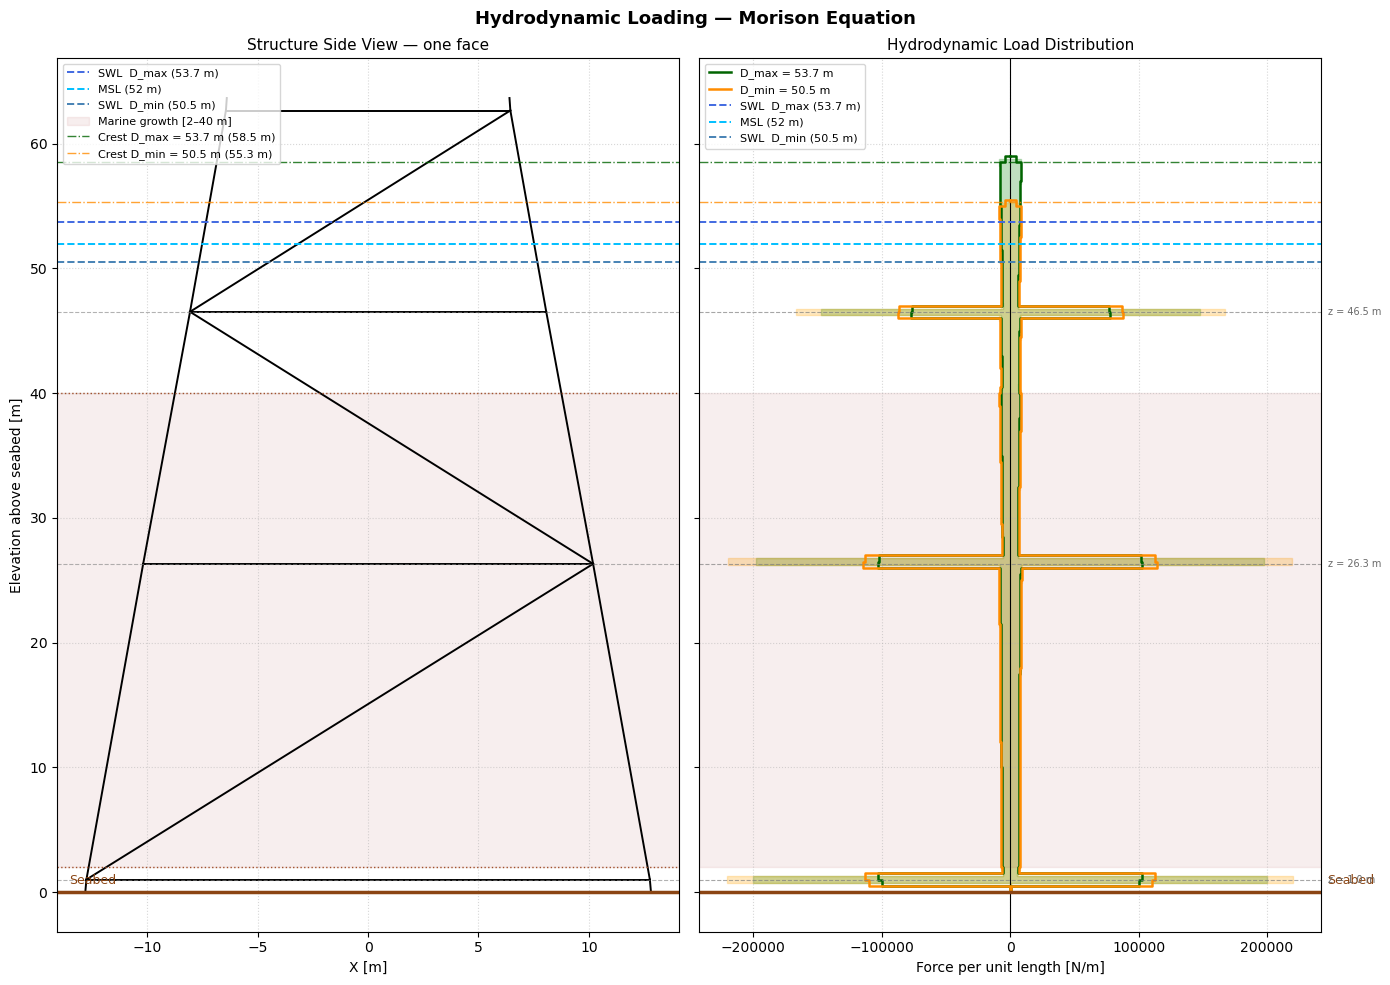

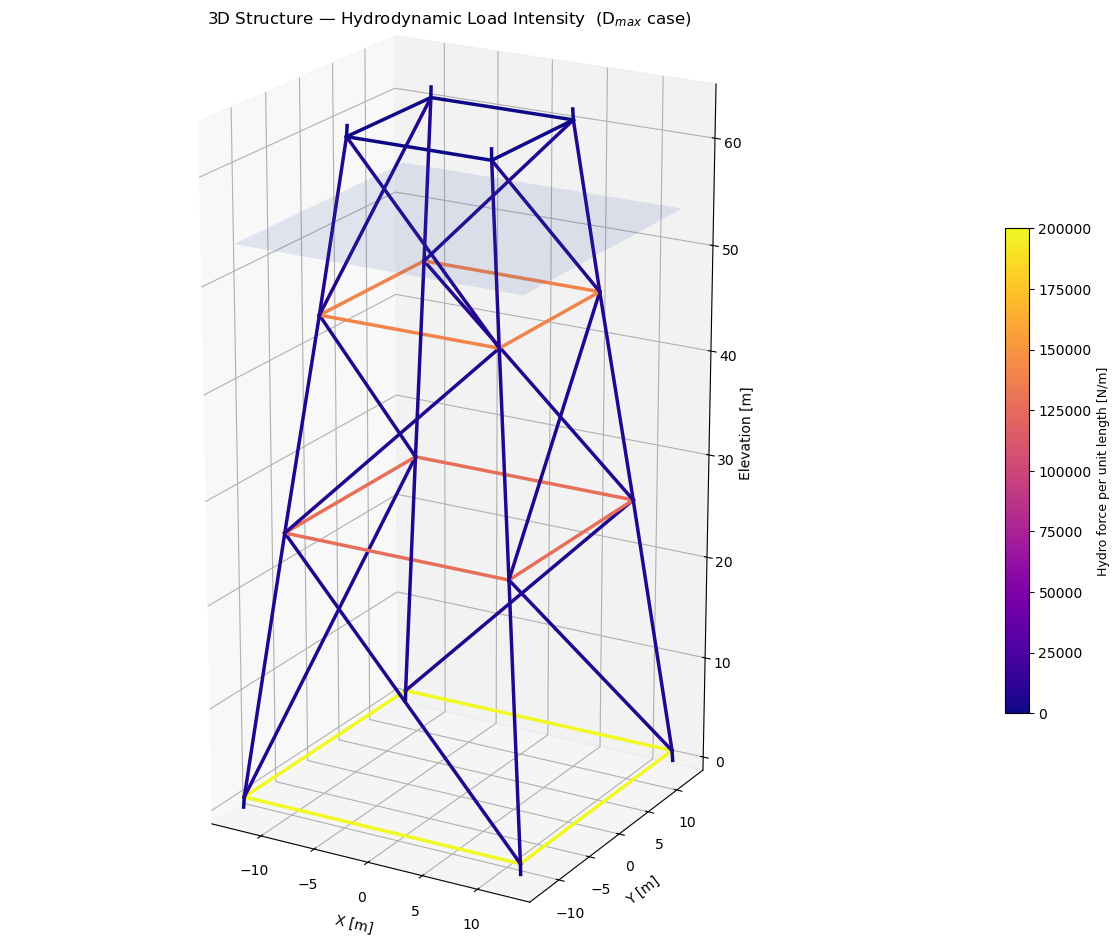

In [ ]:
face_members = [
    m for m in members
    if nodes[m['start']][1] > 0 and nodes[m['end']][1] > 0
]

fig, (ax_s, ax_l) = plt.subplots(1, 2, figsize=(14, 10), sharey=True,
                                  gridspec_kw={'width_ratios': [1, 1]})
fig.subplots_adjust(wspace=0.05)

ax_s.set_title("Structure Side View — one face", fontsize=11)
ax_s.set_xlabel("X [m]")
ax_s.set_ylabel("Elevation above seabed [m]")
ax_s.grid(True, linestyle=':', alpha=0.5)

for m in face_members:
    x_i, y_i, z_i = nodes[m['start']]
    x_j, y_j, z_j = nodes[m['end']]
    ax_s.plot([x_i, x_j], [z_i, z_j], 'k-', linewidth=1.4)

ax_s.axhline(53.7,      color='royalblue',   linestyle='--', linewidth=1.4, label='SWL  D_max (53.7 m)')
ax_s.axhline(z_MSL_abs, color='deepskyblue', linestyle='--', linewidth=1.4, label=f'MSL ({z_MSL_abs:.0f} m)')
ax_s.axhline(50.5,      color='steelblue',   linestyle='--', linewidth=1.4, label='SWL  D_min (50.5 m)')
ax_s.axhspan(z_mg_bot, z_mg_top, alpha=0.08, color='brown',
             label=f'Marine growth [{z_mg_bot:.0f}–{z_mg_top:.0f} m]')
ax_s.axhline(z_mg_bot, color='sienna', linestyle=':', linewidth=1.0)
ax_s.axhline(z_mg_top, color='sienna', linestyle=':', linewidth=1.0)
ax_s.axhline(0, color='saddlebrown', linestyle='-', linewidth=2.5)
ax_s.text(0.02, 0.4, 'Seabed', transform=ax_s.get_yaxis_transform(),
          color='saddlebrown', fontsize=9, va='bottom')

for cr in case_results:
    z_crest_abs = cr['h'] + cr['zeta_cr']
    ax_s.axhline(z_crest_abs, color=cr['line_color'], linestyle='-.', linewidth=1.0,
                 alpha=0.8, label=f"Crest {cr['label']} ({z_crest_abs:.1f} m)")

all_horiz = sorted({z for cr in case_results for z in cr['horiz_abs']})
for z_hz in all_horiz:
    ax_s.axhline(z_hz, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

ax_s.legend(fontsize=8, loc='upper left')

ax_l.set_title("Hydrodynamic Load Distribution", fontsize=11)
ax_l.set_xlabel("Force per unit length [N/m]")
ax_l.grid(True, linestyle=':', alpha=0.5)
ax_l.axvline(0, color='k', linewidth=0.8)

for cr in case_results:
    fa = cr['forces'];  za = cr['z_abs']
    ax_l.fill_betweenx(za, -fa, fa, alpha=0.25, color=cr['fill_color'], step='mid')
    ax_l.step( fa, za, where='mid', color=cr['line_color'], linewidth=1.8, label=cr['label'])
    ax_l.step(-fa, za, where='mid', color=cr['line_color'], linewidth=1.8)

ax_l.axhline(53.7,      color='royalblue',   linestyle='--', linewidth=1.4, label='SWL  D_max (53.7 m)')
ax_l.axhline(z_MSL_abs, color='deepskyblue', linestyle='--', linewidth=1.4, label=f'MSL ({z_MSL_abs:.0f} m)')
ax_l.axhline(50.5,      color='steelblue',   linestyle='--', linewidth=1.4, label='SWL  D_min (50.5 m)')
ax_l.axhspan(z_mg_bot, z_mg_top, alpha=0.08, color='brown')
ax_l.axhline(0, color='saddlebrown', linestyle='-', linewidth=2.5)
ax_l.text(1.01, 0.4, 'Seabed', transform=ax_l.get_yaxis_transform(),
          color='saddlebrown', fontsize=9, va='bottom')

for cr in case_results:
    z_crest_abs = cr['h'] + cr['zeta_cr']
    ax_l.axhline(z_crest_abs, color=cr['line_color'], linestyle='-.', linewidth=1.0, alpha=0.8)

for z_hz in all_horiz:
    ax_l.axhline(z_hz, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    ax_l.text(1.01, z_hz, f'z = {z_hz:.1f} m',
              transform=ax_l.get_yaxis_transform(),
              fontsize=7, color='dimgray', va='center')

ax_l.legend(fontsize=8, loc='upper left')
plt.suptitle('Hydrodynamic Loading — Morison Equation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# ── 3-D load-intensity plot ────────────────────────────────────────────────────
import matplotlib.cm as cm
from matplotlib.colors import Normalize

cr_plot     = case_results[0]
z_abs_plot  = cr_plot['z_abs']
forces_plot = cr_plot['forces']
h_plot      = cr_plot['h']

f_max = float(np.max(np.abs(forces_plot))) if np.max(np.abs(forces_plot)) > 0 else 1.0
norm  = Normalize(vmin=0, vmax=f_max)
cmap  = cm.plasma

fig3d_load = plt.figure(figsize=(12, 10))
ax3 = fig3d_load.add_subplot(111, projection='3d')
ax3.set_title('3D Structure — Hydrodynamic Load Intensity  (D$_{max}$ case)', fontsize=12)
ax3.set_xlabel('X [m]'); ax3.set_ylabel('Y [m]'); ax3.set_zlabel('Elevation [m]')

for m in members:
    xi, yi, zi_node = nodes[m['start']]
    xj, yj, zj_node = nodes[m['end']]
    z_mid_abs = (zi_node + zj_node) / 2.0
    f_mid  = float(np.interp(z_mid_abs, z_abs_plot, forces_plot, left=0.0, right=0.0))
    color  = cmap(norm(abs(f_mid)))
    ax3.plot([xi, xj], [yi, yj], [zi_node, zj_node], color=color, linewidth=2.5)

x_all = [nodes[n][0] for n in nodes]
y_all = [nodes[n][1] for n in nodes]
xx, yy = np.meshgrid([min(x_all), max(x_all)], [min(y_all), max(y_all)])
ax3.plot_surface(xx, yy, np.full_like(xx, h_plot), alpha=0.12, color='royalblue')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig3d_load.colorbar(sm, ax=ax3, shrink=0.5, pad=0.10)
cbar.set_label('Hydro force per unit length [N/m]', fontsize=9)

ax3.set_box_aspect([1, 1, 2])
ax3.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.show()

### Piles

In [25]:
# Foundation reaction and pile design


# INPUT PARAMETERS

# Applied axial load (Pa)
Pa = 30e6  # [N]

# Geometry
t = 0.05            # Wall thickness [m]
D_o = 1.0           # Outer diameter [m]
D_i = D_o - 2*t     # Inner diameter [m]

# Soil layers
L_clay = 15.0                                           # Clay thickness [m]
alpha = 0.6                                             # Adhesion factor for clay
s_u = 200e3                                               # Undrained shear strength [Pa]
Qs_clay = alpha * s_u * np.pi * (D_i + D_o) * L_clay    # Shaft friction in clay [N]

# Unit weights (effective)
gamma_clay = 6.0e3        # [N/m³]
gamma_sand = 800 * 9.81   # [N/m³]

# Shaft friction parameters
beta = 0.46
tau_sf_lim = 120e3  # [Pa]

# End bearing parameters
Nq = 40
q_lim = 10e6  # [Pa]

# Material densities
rho_steel = 7850  # [kg/m³]
rho_water = 1025  # [kg/m³]
g = 9.81          # [m/s²]

# Areas
A_tip = np.pi * (D_o - t) * t  # unplugged pile
A_steel = (np.pi / 4) * (D_o**2 - D_i**2)

# FUNCTIONS

def Qs_sand(L_sand):
 
    integration_term = 0.5 * (gamma_sand * (L_sand ** 2 + 2 * L_clay * L_sand)) + gamma_clay * L_sand * L_clay
    return integration_term * beta * L_sand * np.pi * (D_i + D_o)


def Qb_sand(L_sand):

    sigma_v = gamma_sand * L_sand + gamma_clay * L_clay
    q = min(Nq * sigma_v, q_lim)
    return q * A_tip


def W_pile(L_sand):
 
    L_total = L_clay + L_sand
    return (rho_steel - rho_water) * A_steel * L_total * g


def total_capacity(L_sand):

    return Qs_clay + Qs_sand(L_sand) + Qb_sand(L_sand) - W_pile(L_sand)

# solving algorithm

Q_2 = Qs_clay + Qs_sand(0) - W_pile(0)

if Q_2 >= Pa:
    L_sand_solution = 0
else:
    L_sand_solution = 0.1  # initial guess
    for _ in range(100):
        Q = total_capacity(L_sand_solution)
        if abs(Q - Pa) < 1e-3:
            break
        # Numerical derivative (finite difference)
        dL = 0.01
        Q_plus = total_capacity(L_sand_solution + dL)
        dQ_dL = (Q_plus - Q) / dL
        # Update guess using Newton-Raphson step
        L_sand_solution -= (Q - Pa) / dQ_dL

# OUTPUT

print("===== PILE DESIGN RESULTS =====")
print(f"Sand penetration L_sand: {L_sand_solution:.2f} m")
print(f"Total pile length L_total: {L_clay + L_sand_solution:.2f} m")

print("\n--- Capacity Breakdown ---")
print(f"Qs_clay: {Qs_clay/1e6:.2f} MN")
print(f"Qs_sand: {Qs_sand(L_sand_solution)/1e6:.2f} MN")
print(f"Qb_sand: {Qb_sand(L_sand_solution)/1e6:.2f} MN")
print(f"W_pile:  {W_pile(L_sand_solution)/1e6:.2f} MN")
print(f"Q_total: {total_capacity(L_sand_solution)/1e6:.2f} MN")

# print("\n--- Limit Checks ---")
# print(f"tau_max: {tau_max/1e3:.1f} kPa  (limit: {tau_sf_lim/1e3:.1f} kPa)")
# print(f"q_max:   {q_max/1e6:.2f} MPa (limit: {q_lim/1e6:.2f} MPa)")

===== PILE DESIGN RESULTS =====
Sand penetration L_sand: 5.45 m
Total pile length L_total: 20.45 m

--- Capacity Breakdown ---
Qs_clay: 10.74 MN
Qs_sand: 18.67 MN
Qb_sand: 0.79 MN
W_pile:  0.20 MN
Q_total: 30.00 MN
